# 🍼 Peeko — Baby Product Demand Intelligence
### XGBoost-Powered Restock Prediction Pipeline

This notebook implements the full end-to-end demand prediction system:

| Step | Function | Description |
|---|---|---|
| 1 | `load_data()` | Load 6 Instacart CSV files |
| 2 | `get_baby_product_ids()` | Filter to department 18 (Baby) |
| 3 | `build_user_timeline()` | Cumulative day counter per user |
| 4 | `get_baby_orders()` | Baby purchases with timeline context |
| 5 | `compute_purchase_intervals()` | Days between consecutive purchases |
| 6 | `engineer_features()` | 16 features for XGBoost |
| 7 | `train_xgboost_model()` | Train & evaluate XGBoost regressor |
| 8 | `build_prediction_engine()` | Predict next purchase day per user-product |
| 9 | `convert_to_calendar_dates()` | Map relative days → real calendar dates |
| 10 | `aggregate_demand_predictions()` | Daily demand forecast per product |
| 11 | `generate_restock_action_board()` | Compare demand vs inventory → order list |


## Step 1 — Imports & Configuration

In [63]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Update this path to your Instacart CSV folder ──────────────────────────
DATA_DIR = "D:/MCA/Project/Peeko/Data"

FEATURE_COLS = [
    "interval_mean", "interval_std", "interval_median",
    "interval_min",  "interval_max", "interval_cv",
    "purchase_count", "interval_count", "last_interval", "trend",
    "user_order_count", "user_product_variety",
    "product_buyer_count", "product_global_mean",
    "product_global_std",  "product_global_median",
]

print("Imports OK")
print(f"XGBoost version: {xgb.__version__}")


Imports OK
XGBoost version: 3.2.0


## Step 2 — Load Data

Load all 6 Instacart CSV files. The full dataset contains:
- **49,688** products  |  **3.4M** orders  |  **32M** prior order-product records


In [64]:
product_df             = pd.read_csv(os.path.join(DATA_DIR, "products.csv"))
orders_df              = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
departments_df         = pd.read_csv(os.path.join(DATA_DIR, "departments.csv"))
order_products_prior   = pd.read_csv(os.path.join(DATA_DIR, "order_products__prior.csv"))
order_products_train   = pd.read_csv(os.path.join(DATA_DIR, "order_products__train.csv"))
aisles_df              = pd.read_csv(os.path.join(DATA_DIR, "aisles.csv"))

print(f"Products            : {len(product_df):>10,}")
print(f"Orders              : {len(orders_df):>10,}")
print(f"Prior order-products: {len(order_products_prior):>10,}")
print(f"Departments         : {len(departments_df):>10,}")
print()
product_df.head(3)


Products            :     49,688
Orders              :  3,421,083
Prior order-products: 32,434,489
Departments         :         21



,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


## Step 3 — Filter Baby Department Products

Department ID **18** = Baby. We narrow from 49,688 products down to baby SKUs only.
This reduces the downstream order-product join by ~94%.


In [65]:
baby_product_ids = product_df.loc[
    product_df["department_id"] == 18, "product_id"
]

print(f"Total products   : {len(product_df):,}")
print(f"Baby products    : {len(baby_product_ids):,}")
print(f"Reduction        : {(1 - len(baby_product_ids)/len(product_df))*100:.1f}%")

# Show baby products sample
product_df[product_df["department_id"] == 18].head(8)


Total products   : 49,688
Baby products    : 1,081
Reduction        : 97.8%


,product_id,product_name,aisle_id,department_id
14,15,Overnight Diapers Size 6,56,18
62,63,Banana & Sweet Potato Organic Teething Wafers,92,18
63,64,Autumn Vegetable & Turkey Dinner with Lil' Bit...,92,18
93,94,Organic Blueberry Blitz Fruit & Veggie Smoothi...,92,18
105,106,Organic Yummy Tummy Maple & Brown Sugar Instan...,92,18
218,219,Totz Toothbrush Extra Soft 18+ Months,82,18
308,309,Graduates Lil' Entrees Spiral Pasta In Turkey ...,92,18
425,426,2nd Foods Bananas,92,18


## Step 4 — Build User Purchase Timeline

For each user, compute a **cumulative day counter** across all their prior orders.
This converts relative `days_since_prior_order` into an absolute `user_timeline_day`
so we can measure the real gap between specific product purchases.

> Example for User 9:  
> Order 1 → Day 0 · Order 2 → Day 14 · Order 3 → Day 36 · Order 4 → Day 54


In [66]:
prior_orders = orders_df[orders_df["eval_set"] == "prior"].copy()
prior_orders = prior_orders.sort_values(["user_id", "order_number"])
prior_orders["days_since_prior_order"] = prior_orders["days_since_prior_order"].fillna(0)
prior_orders["user_timeline_day"] = (
    prior_orders.groupby("user_id")["days_since_prior_order"].cumsum()
)

print(f"Prior orders: {len(prior_orders):,}")
print(f"Unique users: {prior_orders['user_id'].nunique():,}")
print()
prior_orders[["user_id","order_number","days_since_prior_order","user_timeline_day"]].head(8)


Prior orders: 3,214,874
Unique users: 206,209



,user_id,order_number,days_since_prior_order,user_timeline_day
0,1,1,0.00,0.00
1,1,2,15.00,15.00
2,1,3,21.00,36.00
3,1,4,29.00,65.00
4,1,5,28.00,93.00
5,1,6,19.00,112.00
6,1,7,20.00,132.00
7,1,8,14.00,146.00


## Step 5 — Get Baby Orders with Timeline Context

Filter the 32M prior order-product rows to baby products only,
then join with the user timeline to attach `user_timeline_day` to each purchase.


In [67]:
baby_order_products = order_products_prior[
    order_products_prior["product_id"].isin(baby_product_ids)
]

baby_orders = baby_order_products.merge(
    prior_orders[["order_id","user_id","order_number",
                  "user_timeline_day","days_since_prior_order"]],
    on="order_id", how="inner"
)

print(f"Baby purchase events : {len(baby_orders):,}")
print(f"Unique baby products : {baby_orders['product_id'].nunique():,}")
print(f"Unique users         : {baby_orders['user_id'].nunique():,}")
baby_orders.head(5)


Baby purchase events : 423,802
Unique baby products : 1,081
Unique users         : 33,730


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,user_timeline_day,days_since_prior_order
0,10,22122,8,1,135442,4,21.00,8.00
1,10,34134,9,1,135442,4,21.00,8.00
2,18,38985,9,1,118860,3,13.00,6.00
3,18,45495,16,1,118860,3,13.00,6.00
4,18,32018,17,1,118860,3,13.00,6.00


## Step 6 — Compute Purchase Intervals

For each **(user, product)** pair, compute the number of days between consecutive
purchases using `user_timeline_day.diff()`.

The first purchase of any product by any user will always produce **NaN** — this is
expected and will be filtered out in the feature engineering step.


In [68]:
baby_orders = baby_orders.sort_values(["user_id","product_id","order_number"])
baby_orders["true_days_between_purchase"] = (
    baby_orders
    .groupby(["user_id","product_id"])["user_timeline_day"]
    .diff()
)

valid_intervals = baby_orders["true_days_between_purchase"].dropna()
print(f"Total rows             : {len(baby_orders):,}")
print(f"Valid intervals (non-NaN): {len(valid_intervals):,}")
print()
print("Interval distribution (days):")
print(valid_intervals.describe().round(1))


Total rows             : 423,802
Valid intervals (non-NaN): 245,369

Interval distribution (days):
count   245369.00
mean        26.10
std         32.50
min          0.00
25%          7.00
50%         15.00
75%         30.00
max        344.00
Name: true_days_between_purchase, dtype: float64


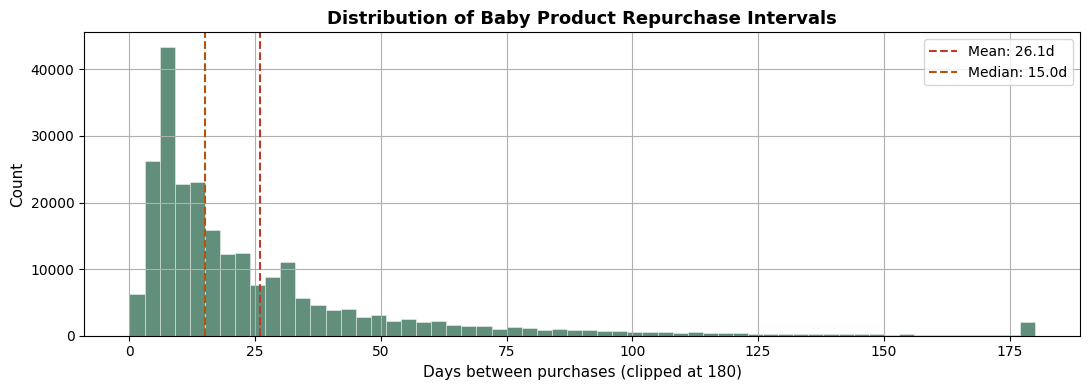

In [69]:
fig, ax = plt.subplots(figsize=(11, 4))
valid_intervals.clip(upper=180).hist(bins=60, ax=ax,
    color="#2d6a4f", alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axvline(valid_intervals.mean(),   color="#c0392b", linestyle="--", linewidth=1.5,
           label=f"Mean: {valid_intervals.mean():.1f}d")
ax.axvline(valid_intervals.median(), color="#b45309", linestyle="--", linewidth=1.5,
           label=f"Median: {valid_intervals.median():.1f}d")
ax.set_xlabel("Days between purchases (clipped at 180)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Distribution of Baby Product Repurchase Intervals", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


## Step 7 — Engineer Features for XGBoost

Build a **16-feature matrix** from purchase history. Features are grouped into three levels:

**User-product level** — how *this user* buys *this specific product*:
- `interval_mean`, `interval_std`, `interval_median`, `interval_min`, `interval_max`
- `interval_cv` — coefficient of variation (0 = perfectly regular buyer)
- `purchase_count`, `interval_count`, `last_interval`
- `trend` — last_interval − interval_mean  (speeding up or slowing down?)

**User level** — general buying behaviour of this user:
- `user_order_count`, `user_product_variety`

**Product level** — how this product is bought across ALL users:
- `product_buyer_count`, `product_global_mean`, `product_global_std`, `product_global_median`

> **Zero data leakage**: all features use `.expanding().shift(1)` — only information
> available *before* the current interval is used to predict it.


In [70]:
df = baby_orders.dropna(subset=["true_days_between_purchase"]).copy()
df = df.sort_values(["user_id","product_id","order_number"])

grp = df.groupby(["user_id","product_id"])["true_days_between_purchase"]

df["interval_mean"]   = grp.transform(lambda x: x.expanding().mean().shift(1))
df["interval_std"]    = grp.transform(lambda x: x.expanding().std().shift(1).fillna(0))
df["interval_median"] = grp.transform(lambda x: x.expanding().median().shift(1))
df["interval_min"]    = grp.transform(lambda x: x.expanding().min().shift(1))
df["interval_max"]    = grp.transform(lambda x: x.expanding().max().shift(1))
df["interval_count"]  = grp.transform(lambda x: x.expanding().count().shift(1).fillna(0))
df["last_interval"]   = grp.transform(lambda x: x.shift(1))

df["interval_cv"]    = np.where(df["interval_mean"] > 0,
                                df["interval_std"] / df["interval_mean"], 0)
df["purchase_count"] = df["interval_count"] + 1
df["trend"]          = df["last_interval"] - df["interval_mean"]

# User-level features
user_stats = (baby_orders.groupby("user_id")
    .agg(user_order_count    =("order_number","nunique"),
         user_product_variety=("product_id",  "nunique"))
    .reset_index())
df = df.merge(user_stats, on="user_id", how="left")

# Product-level features
prod_stats = (df.groupby("product_id")["true_days_between_purchase"]
    .agg(product_buyer_count  ="count",
         product_global_mean  ="mean",
         product_global_std   ="std",
         product_global_median="median")
    .reset_index())
prod_stats["product_global_std"] = prod_stats["product_global_std"].fillna(0)
df = df.merge(prod_stats, on="product_id", how="left")

feature_df = df.dropna(subset=FEATURE_COLS).copy()
feature_df["target"] = feature_df["true_days_between_purchase"]
feature_df = feature_df[["user_id","product_id","order_number"] + FEATURE_COLS + ["target"]]

print(f"Feature matrix: {feature_df.shape[0]:,} rows × {len(FEATURE_COLS)} features")
feature_df.head(5)


Feature matrix: 172,874 rows × 16 features


,user_id,product_id,order_number,interval_mean,interval_std,interval_median,interval_min,interval_max,interval_cv,purchase_count,interval_count,last_interval,trend,user_order_count,user_product_variety,product_buyer_count,product_global_mean,product_global_std,product_global_median,target
2,32,49215,4,20.00,0.00,20.00,20.00,20.00,0.00,2.00,1.00,20.00,0.00,4,2,2883,40.61,42.49,28.00,1.00
3,32,49215,5,10.50,13.44,10.50,1.00,20.00,1.28,3.00,2.00,1.00,-9.50,4,2,2883,40.61,42.49,28.00,30.00
5,37,17170,7,16.00,0.00,16.00,16.00,16.00,0.00,2.00,1.00,16.00,0.00,4,2,702,31.23,33.29,21.00,20.00
8,50,5922,50,80.00,0.00,80.00,80.00,80.00,0.00,2.00,1.00,80.00,0.00,4,2,1907,31.02,39.61,17.00,53.00
11,59,47719,5,30.00,0.00,30.00,30.00,30.00,0.00,2.00,1.00,30.00,0.00,7,8,697,23.82,29.00,14.00,17.00


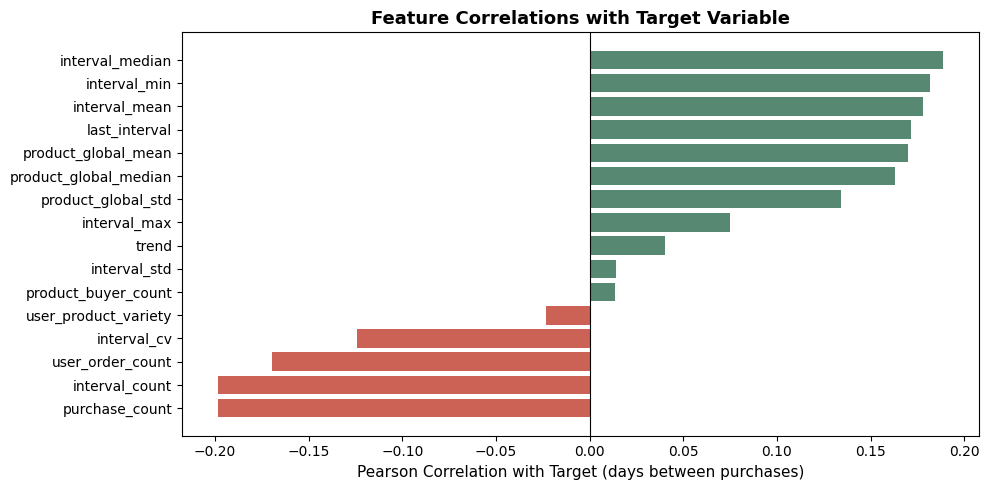

In [71]:
# Feature correlations with target
corrs = feature_df[FEATURE_COLS].corrwith(feature_df["target"]).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#c0392b" if v < 0 else "#2d6a4f" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target (days between purchases)", fontsize=11)
ax.set_title("Feature Correlations with Target Variable", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Step 8 — Train XGBoost Model

Split by **user groups** using `GroupShuffleSplit` — all rows for a given user
land in either train OR test, never both. This prevents leakage and simulates
real deployment where we predict for unseen users.

**Model:** XGBoost Regressor  
**Target:** `true_days_between_purchase` (continuous, in days)  
**Split:** 80% train / 20% test by user group  
**Regularisation:** L1 (α=0.1) + L2 (λ=1.0) + early stopping


In [72]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(feature_df, groups=feature_df["user_id"]))

X = feature_df[FEATURE_COLS];  y = feature_df["target"]
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

# Verify zero leakage
train_users = set(feature_df.iloc[train_idx]["user_id"])
test_users  = set(feature_df.iloc[test_idx]["user_id"])
print(f"Train: {len(X_tr):,} rows  |  {len(train_users):,} users")
print(f"Test : {len(X_te):,} rows  |  {len(test_users):,} users")
print(f"User overlap: {len(train_users & test_users)}  ← must be 0")


Train: 137,945 rows  |  10,154 users
Test : 34,929 rows  |  2,539 users
User overlap: 0  ← must be 0


In [73]:
model = xgb.XGBRegressor(
    n_estimators         = 400,
    max_depth            = 6,
    learning_rate        = 0.05,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    min_child_weight     = 5,
    reg_alpha            = 0.1,
    reg_lambda           = 1.0,
    objective            = "reg:squarederror",
    random_state         = 42,
    n_jobs               = -1,
    early_stopping_rounds= 20,
    eval_metric          = "mae",
)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
print(f"Training complete.")
print(f"Best iteration : {model.best_iteration}")
print(f"Best MAE score : {model.best_score:.4f} days")


Training complete.
Best iteration : 91
Best MAE score : 15.4610 days


## Step 9 — Evaluate Model

Key metrics explained:
- **MAE** — average prediction error in days. Lower = better.
- **RMSE** — penalises large errors more than MAE. Lower = better.
- **R²** — proportion of variance explained. Positive = better than guessing the global mean.
- **Within 7 days %** — predictions within 1 week of truth.
- **Within 14 days %** — predictions within 2 weeks of truth.


In [74]:
preds  = np.clip(model.predict(X_te), 1, None)
errors = np.abs(preds - y_te.values)

mae  = mean_absolute_error(y_te, preds)
rmse = np.sqrt(mean_squared_error(y_te, preds))
r2   = r2_score(y_te, preds)
w7   = (errors <= 7).mean()  * 100
w14  = (errors <= 14).mean() * 100

print("=" * 48)
print("  XGBoost Model Evaluation")
print("=" * 48)
print(f"  MAE                : {mae:.2f} days")
print(f"  RMSE               : {rmse:.2f} days")
print(f"  R² Score           : {r2:.4f}")
print(f"  Within  7 days     : {w7:.1f}%")
print(f"  Within 14 days     : {w14:.1f}%")
print(f"  Test samples       : {len(y_te):,}")
print(f"  Best iteration     : {model.best_iteration}")
print("=" * 48)


  XGBoost Model Evaluation
  MAE                : 15.46 days
  RMSE               : 25.70 days
  R² Score           : 0.1033
  Within  7 days     : 33.5%
  Within 14 days     : 63.7%
  Test samples       : 34,929
  Best iteration     : 91


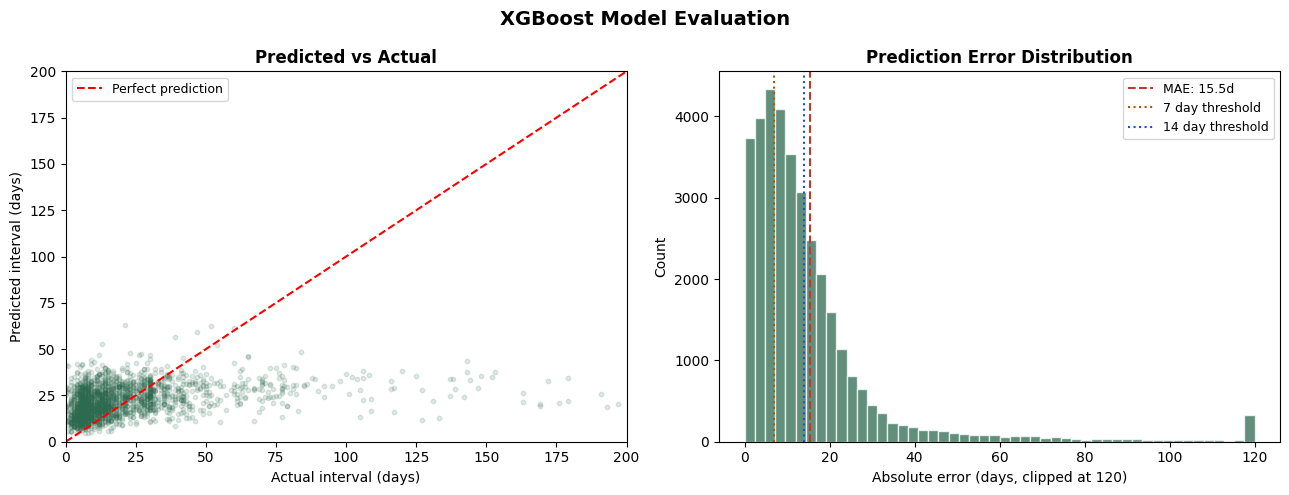

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("XGBoost Model Evaluation", fontsize=14, fontweight="bold")

# Predicted vs Actual
sample_idx = y_te.sample(min(2000, len(y_te)), random_state=42).index
y_s = y_te.loc[sample_idx];  p_s = model.predict(X_te.loc[sample_idx])
max_v = min(200, max(y_s.max(), p_s.max()))
axes[0].scatter(y_s, p_s, alpha=0.15, s=10, color="#2d6a4f")
axes[0].plot([0, max_v], [0, max_v], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual interval (days)"); axes[0].set_ylabel("Predicted interval (days)")
axes[0].set_title("Predicted vs Actual", fontweight="bold")
axes[0].set_xlim(0, max_v); axes[0].set_ylim(0, max_v); axes[0].legend(fontsize=9)

# Error distribution
axes[1].hist(errors.clip(max=120), bins=50, color="#2d6a4f", alpha=0.75, edgecolor="white")
axes[1].axvline(mae,  color="#c0392b", linestyle="--", linewidth=1.5, label=f"MAE: {mae:.1f}d")
axes[1].axvline(7,    color="#b45309", linestyle=":",  linewidth=1.5, label="7 day threshold")
axes[1].axvline(14,   color="#1d4ed8", linestyle=":",  linewidth=1.5, label="14 day threshold")
axes[1].set_xlabel("Absolute error (days, clipped at 120)"); axes[1].set_ylabel("Count")
axes[1].set_title("Prediction Error Distribution", fontweight="bold"); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


Top 10 most important features:
              feature  importance  importance_pct
         interval_min        0.22           22.10
      interval_median        0.18           18.10
       purchase_count        0.13           13.10
       interval_count        0.09            9.20
        interval_mean        0.06            6.10
        last_interval        0.06            5.60
  product_global_mean        0.04            3.90
   product_global_std        0.04            3.70
product_global_median        0.04            3.60
     user_order_count        0.03            3.10


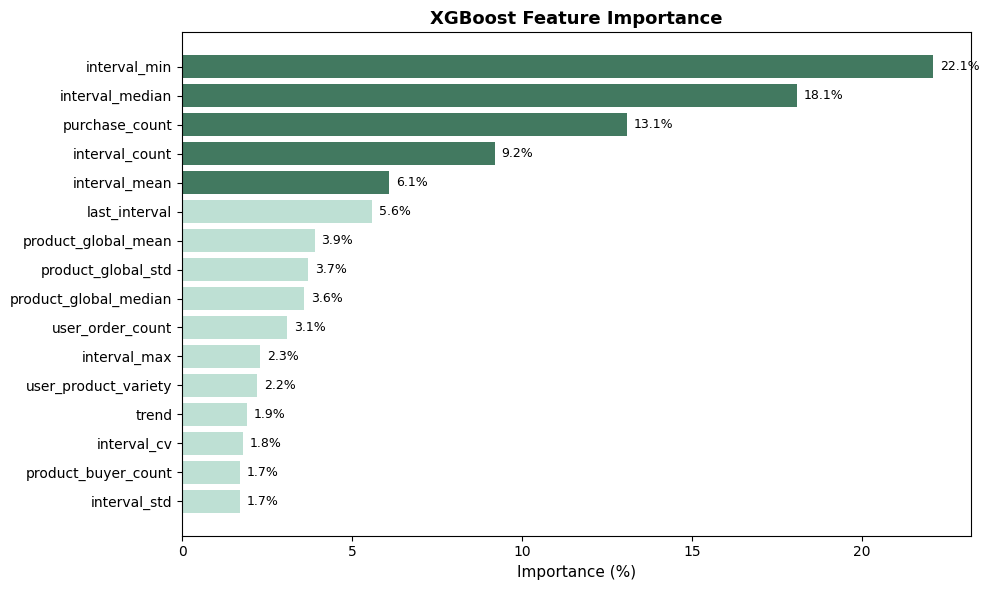

In [76]:
# Feature importance
imp = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
imp["importance_pct"] = (imp["importance"] / imp["importance"].sum() * 100).round(1)

print("Top 10 most important features:")
print(imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2d6a4f" if i < 5 else "#b7ddd0" for i in range(len(imp))]
ax.barh(imp["feature"][::-1], imp["importance_pct"][::-1], color=colors[::-1], alpha=0.9)
for i, pct in enumerate(imp["importance_pct"][::-1]):
    ax.text(pct + 0.2, i, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Importance (%)", fontsize=11)
ax.set_title("XGBoost Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Step 10 — Build Prediction Engine

For each **(user, product)** pair, take the **latest feature snapshot**
(most recent interval row) and use the trained XGBoost model to predict the
next repurchase interval. Then add that to the user's last known purchase day.

Only pairs with `interval_count >= 2` are included (minimum 2 observed intervals
for statistical confidence).


In [77]:
MIN_INTERVALS = 2

# Get latest feature snapshot per (user, product)
latest = (
    feature_df
    .sort_values(["user_id","product_id","order_number"])
    .groupby(["user_id","product_id"])
    .last()
    .reset_index()
)
latest = latest[latest["interval_count"] >= MIN_INTERVALS].copy()

# XGBoost prediction
latest["predicted_interval"] = np.clip(model.predict(latest[FEATURE_COLS]), 1, None)

# Last purchase day per (user, product)
last_purchases = (
    baby_orders
    .groupby(["user_id","product_id"])["user_timeline_day"]
    .max()
    .reset_index()
    .rename(columns={"user_timeline_day": "last_purchase_day"})
)

prediction_engine = latest.merge(last_purchases, on=["user_id","product_id"], how="inner")
prediction_engine["predicted_next_purchase_day"] = (
    prediction_engine["last_purchase_day"] + prediction_engine["predicted_interval"]
)

print(f"User-product pairs with predictions: {len(prediction_engine):,}")
print()
prediction_engine[["user_id","product_id","last_purchase_day",
                   "predicted_interval","predicted_next_purchase_day"]].head(8)


User-product pairs with predictions: 27,439



,user_id,product_id,last_purchase_day,predicted_interval,predicted_next_purchase_day
0,32,49215,81.00,41.71,122.71
1,59,47719,81.00,26.61,107.61
2,77,47167,148.00,38.17,186.17
3,87,48790,232.00,20.56,252.56
4,140,1907,350.00,14.81,364.81
5,140,2657,363.00,18.73,381.73
6,140,7051,338.00,26.48,364.48
7,140,10036,359.00,17.32,376.32


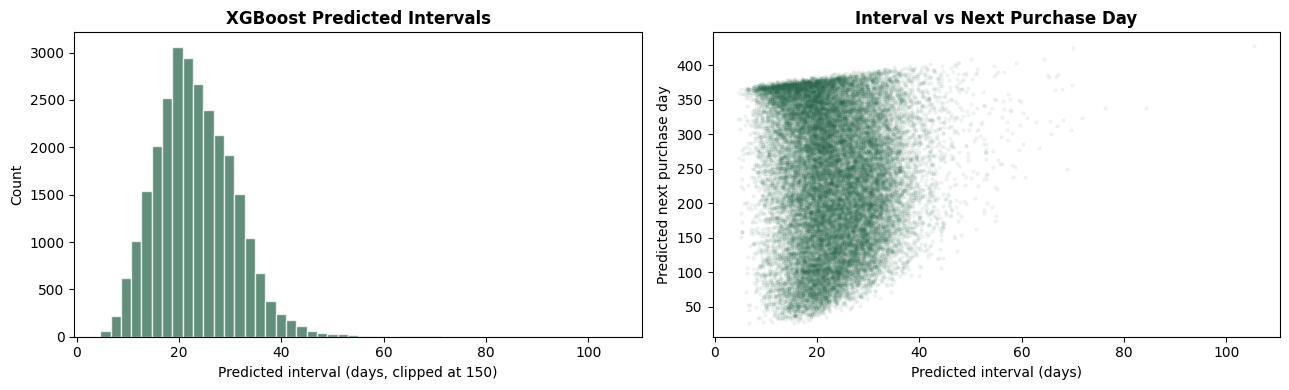

In [78]:
# Distribution of predicted intervals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prediction_engine["predicted_interval"].clip(upper=150),
             bins=50, color="#2d6a4f", alpha=0.75, edgecolor="white")
axes[0].set_xlabel("Predicted interval (days, clipped at 150)"); axes[0].set_ylabel("Count")
axes[0].set_title("XGBoost Predicted Intervals", fontweight="bold")

axes[1].scatter(prediction_engine["predicted_interval"].clip(upper=150),
                prediction_engine["predicted_next_purchase_day"].clip(upper=5000),
                alpha=0.05, s=5, color="#2d6a4f")
axes[1].set_xlabel("Predicted interval (days)"); axes[1].set_ylabel("Predicted next purchase day")
axes[1].set_title("Interval vs Next Purchase Day", fontweight="bold")

plt.tight_layout(); plt.show()


## Step 11 — Convert Timeline Days → Calendar Dates

The dataset uses **relative day numbers**, not real calendar dates.
We anchor the highest observed timeline day to **today's actual date**,
then offset every predicted day accordingly.

`predicted_calendar_date = today + (predicted_day − global_max_day)`


In [79]:
today          = pd.Timestamp.today()
global_max_day = baby_orders["user_timeline_day"].max()

prediction_engine["days_from_today"] = (
    prediction_engine["predicted_next_purchase_day"] - global_max_day
)
prediction_engine["predicted_calendar_date"] = (
    today + pd.to_timedelta(prediction_engine["days_from_today"], unit="D")
)

print(f"Today            : {today.date()}")
print(f"Global max day   : {global_max_day:.0f}")
print(f"Forecast range   : {prediction_engine['predicted_calendar_date'].min().date()} "
      f"→ {prediction_engine['predicted_calendar_date'].max().date()}")
prediction_engine[["user_id","product_id","days_from_today","predicted_calendar_date"]].head(6)


Today            : 2026-03-06
Global max day   : 365
Forecast range   : 2025-04-02 → 2026-05-08


,user_id,product_id,days_from_today,predicted_calendar_date
0,32,49215,-242.29,2025-07-07 10:07:16.299276316
1,59,47719,-257.39,2025-06-22 07:34:50.016317325
2,77,47167,-178.83,2025-09-08 21:02:14.944295847
3,87,48790,-112.44,2025-11-14 06:18:07.788534127
4,140,1907,-0.19,2026-03-06 12:25:22.435140568
5,140,2657,16.73,2026-03-23 10:25:57.399129828


## Step 12 — Aggregate Daily Demand Forecast

Group by **(predicted_calendar_date, product_id)** and count the number of users
predicted to buy each product on each date. That count = **predicted demand units**.


In [80]:
final_predictions = (
    prediction_engine[["user_id","product_id","predicted_calendar_date"]]
    .groupby(["predicted_calendar_date","product_id"])
    .agg(predicted_demand_units=("user_id","count"))
    .reset_index()
)

print(f"Demand forecast rows  : {len(final_predictions):,}")
print(f"Unique products       : {final_predictions['product_id'].nunique():,}")
print(f"Unique forecast dates : {final_predictions['predicted_calendar_date'].nunique():,}")
final_predictions.head(8)


Demand forecast rows  : 27,438
Unique products       : 832
Unique forecast dates : 27,392


,predicted_calendar_date,product_id,predicted_demand_units
0,2025-04-02 05:57:14.852743109,31504,1
1,2025-04-02 10:51:51.044454536,26466,1
2,2025-04-03 01:28:19.617147406,46608,1
3,2025-04-03 01:47:51.309041937,16507,1
4,2025-04-03 21:25:10.157918892,32106,1
5,2025-04-03 22:15:10.002279244,765,1
6,2025-04-05 17:42:58.907918892,5085,1
7,2025-04-06 18:54:44.834432559,29479,1


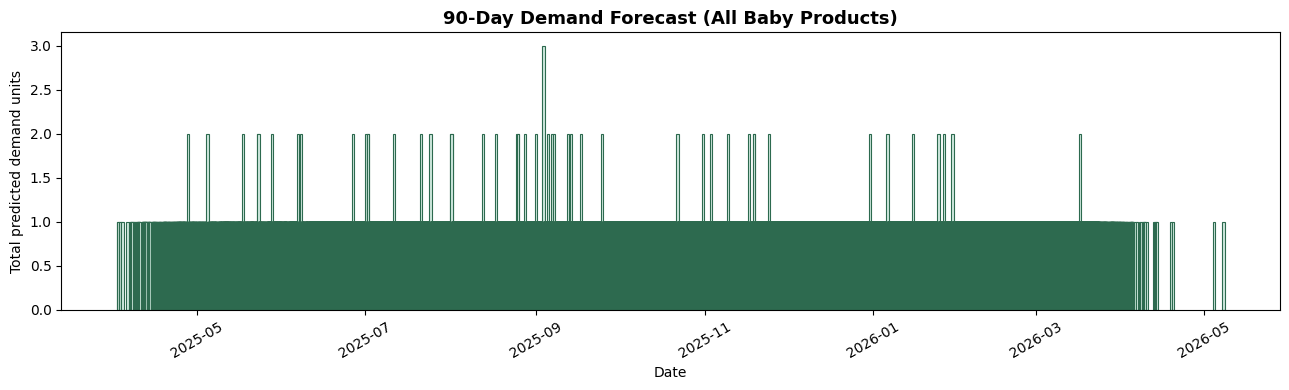

In [81]:
# Daily total demand chart
daily = (
    final_predictions
    .groupby("predicted_calendar_date")["predicted_demand_units"]
    .sum()
    .reset_index()
    .sort_values("predicted_calendar_date")
)
daily["date"] = pd.to_datetime(daily["predicted_calendar_date"])
daily_30 = daily[daily["date"] <= today + pd.Timedelta(days=90)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily_30["date"], daily_30["predicted_demand_units"],
       color="#d1e9df", edgecolor="#2d6a4f", linewidth=0.8, width=0.8)
ax.set_xlabel("Date"); ax.set_ylabel("Total predicted demand units")
ax.set_title("90-Day Demand Forecast (All Baby Products)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## Step 13 — Generate Restock Action Board

Compare total forecasted demand per product against current inventory.
Aggregate across all forecast dates so each product appears **exactly once**.

- `total_demand_units` = sum of demand across all future dates
- `current_stock`      = simulated inventory (replace with real DB query in production)
- `units_to_order`     = max(0, total_demand − current_stock)
- `next_restock_date`  = earliest date stock is needed
- `date_count`         = number of separate forecast dates for this product


In [82]:
np.random.seed(42)
inventory_df = pd.DataFrame({
    "product_id":    baby_product_ids,
    "current_stock": np.random.randint(0, 40, size=len(baby_product_ids)),
})

action_board = final_predictions.merge(inventory_df, on="product_id", how="left")
action_board["current_stock"] = action_board["current_stock"].fillna(0)

aggregated = (
    action_board
    .groupby("product_id", as_index=False)
    .agg(
        total_demand_units =("predicted_demand_units",  "sum"),
        current_stock      =("current_stock",           "min"),
        next_restock_date  =("predicted_calendar_date", "min"),
        date_count         =("predicted_calendar_date", "count"),
    )
)

aggregated["units_to_order"] = np.where(
    aggregated["total_demand_units"] > aggregated["current_stock"],
    aggregated["total_demand_units"] - aggregated["current_stock"],
    0
)

critical_restock_list = (
    aggregated[aggregated["units_to_order"] > 0]
    .copy()
    .sort_values("units_to_order", ascending=False)
    .reset_index(drop=True)
)

print(f"Total baby products          : {len(baby_product_ids):,}")
print(f"Products needing restock     : {len(critical_restock_list):,}")
print(f"Total units to order         : {critical_restock_list['units_to_order'].sum():,}")
print()
critical_restock_list.head(10)


Total baby products          : 1,081
Products needing restock     : 296
Total units to order         : 19,951



,product_id,total_demand_units,current_stock,next_restock_date,date_count,units_to_order
0,43875,621,30,2025-04-10 09:42:06.448202091,621,591
1,34134,590,4,2025-04-13 08:10:08.784627874,590,586
2,2611,547,13,2025-04-26 14:42:54.293661081,547,534
3,3020,497,23,2025-04-17 10:25:45.039510685,497,474
4,21162,420,25,2025-04-23 23:45:58.039998973,420,395
5,44471,405,30,2025-04-27 17:15:33.595418892,405,375
6,5114,365,25,2025-04-13 01:45:12.281942325,365,340
7,18176,353,15,2025-04-29 07:20:54.011678658,353,338
8,49215,361,28,2025-05-05 22:54:18.741903262,361,333
9,5491,363,38,2025-04-09 07:00:07.090902289,363,325


Urgency Breakdown:
  Critical   :   175  (59.1%)
  High       :    41  (13.9%)
  Medium     :    26  (8.8%)
  Low        :    54  (18.2%)


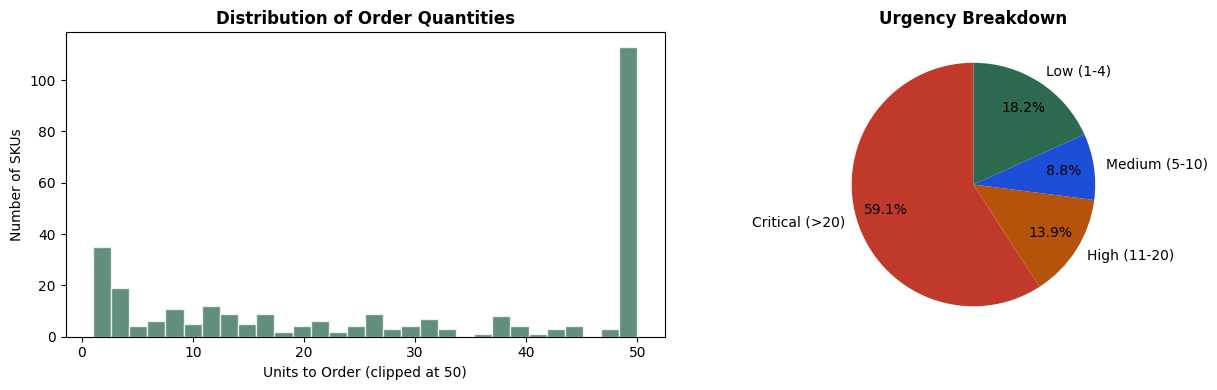

In [83]:
# Urgency breakdown
def urgency(u): 
    return "Critical" if u > 20 else "High" if u > 10 else "Medium" if u >= 5 else "Low"

critical_restock_list["urgency"] = critical_restock_list["units_to_order"].apply(urgency)
urg_counts = critical_restock_list["urgency"].value_counts()
print("Urgency Breakdown:")
for level, color in [("Critical","#c0392b"),("High","#b45309"),("Medium","#1d4ed8"),("Low","#2d6a4f")]:
    count = urg_counts.get(level, 0)
    pct   = count / len(critical_restock_list) * 100 if len(critical_restock_list) else 0
    print(f"  {level:<10} : {count:>5,}  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Order qty distribution
axes[0].hist(critical_restock_list["units_to_order"].clip(upper=50),
             bins=30, color="#2d6a4f", alpha=0.75, edgecolor="white")
axes[0].set_xlabel("Units to Order (clipped at 50)"); axes[0].set_ylabel("Number of SKUs")
axes[0].set_title("Distribution of Order Quantities", fontweight="bold")

# Urgency pie
labels  = ["Critical (>20)", "High (11-20)", "Medium (5-10)", "Low (1-4)"]
vals    = [urg_counts.get(u, 0) for u in ["Critical","High","Medium","Low"]]
colors  = ["#c0392b","#b45309","#1d4ed8","#2d6a4f"]
wedges, texts, autotexts = axes[1].pie(
    [v for v in vals if v > 0],
    labels   =[l for l, v in zip(labels, vals) if v > 0],
    colors   =[c for c, v in zip(colors, vals) if v > 0],
    autopct  ="%1.1f%%", startangle=90, pctdistance=0.75
)
axes[1].set_title("Urgency Breakdown", fontweight="bold")

plt.tight_layout(); plt.show()


## Step 14 — Pipeline Summary

In [84]:
print("=" * 58)
print("  PEEKO — XGBoost PIPELINE SUMMARY")
print("=" * 58)
print(f"  Baby SKUs tracked          : {len(baby_product_ids):>8,}")
print(f"  Purchase intervals used    : {len(feature_df):>8,}")
print(f"  XGBoost features           : {len(FEATURE_COLS):>8,}")
print(f"  Training samples           : {len(X_tr):>8,}")
print(f"  Test samples               : {len(X_te):>8,}")
print(f"  Best iteration             : {model.best_iteration:>8,}")
print("-" * 58)
print(f"  MAE                        : {mae:>7.2f} days")
print(f"  RMSE                       : {rmse:>7.2f} days")
print(f"  R² Score                   : {r2:>8.4f}")
print(f"  Within  7 days             : {w7:>7.1f} %")
print(f"  Within 14 days             : {w14:>7.1f} %")
print("-" * 58)
print(f"  Forecast rows generated    : {len(final_predictions):>8,}")
print(f"  Critical SKUs flagged      : {len(critical_restock_list):>8,}")
print(f"  Total units to order       : {critical_restock_list['units_to_order'].sum():>8,}")
print("=" * 58)
print()
print("Top 5 most urgent restocks:")
cols = ["product_id","next_restock_date","total_demand_units","current_stock","units_to_order","date_count"]
print(critical_restock_list[cols].head(5).to_string(index=False))


  PEEKO — XGBoost PIPELINE SUMMARY
  Baby SKUs tracked          :    1,081
  Purchase intervals used    :  172,874
  XGBoost features           :       16
  Training samples           :  137,945
  Test samples               :   34,929
  Best iteration             :       91
----------------------------------------------------------
  MAE                        :   15.46 days
  RMSE                       :   25.70 days
  R² Score                   :   0.1033
  Within  7 days             :    33.5 %
  Within 14 days             :    63.7 %
----------------------------------------------------------
  Forecast rows generated    :   27,438
  Critical SKUs flagged      :      296
  Total units to order       :   19,951

Top 5 most urgent restocks:
 product_id             next_restock_date  total_demand_units  current_stock  units_to_order  date_count
      43875 2025-04-10 09:42:06.448202091                 621             30             591         621
      34134 2025-04-13 08:10:08.784627